In [21]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# data (as pandas dataframes) 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 
  
# metadata 
print(bike_sharing.metadata) 
  
# variable information 
print(bike_sharing.variables) 


{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

The goal of this dataset is to predict the total number of rented bikes (cnt)
based on weather conditions, seasonal factors and time variables.

The target variable "cnt" represents the total number of rented bikes
and is a continuous numerical value. Therefore regression models can
be used to predict this variable.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from ucimlrepo import fetch_ucirepo

bike_sharing = fetch_ucirepo(id=275)

X = bike_sharing.data.features
y = bike_sharing.data.targets

df = pd.concat([X,y], axis=1)

df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


EDA

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


The dataset contains 17,379 observations and 17 variables. Most
variables are numerical and there are no obvious missing values.

In [25]:
df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

No missing values were detected in the dataset.

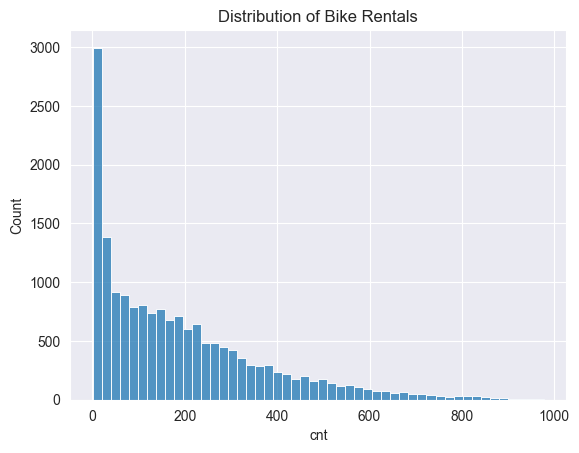

In [26]:
sns.histplot(df["cnt"], bins=50)
plt.title("Distribution of Bike Rentals")
plt.show()

The target variable is slightly skewed but still suitable for regression
modeling.

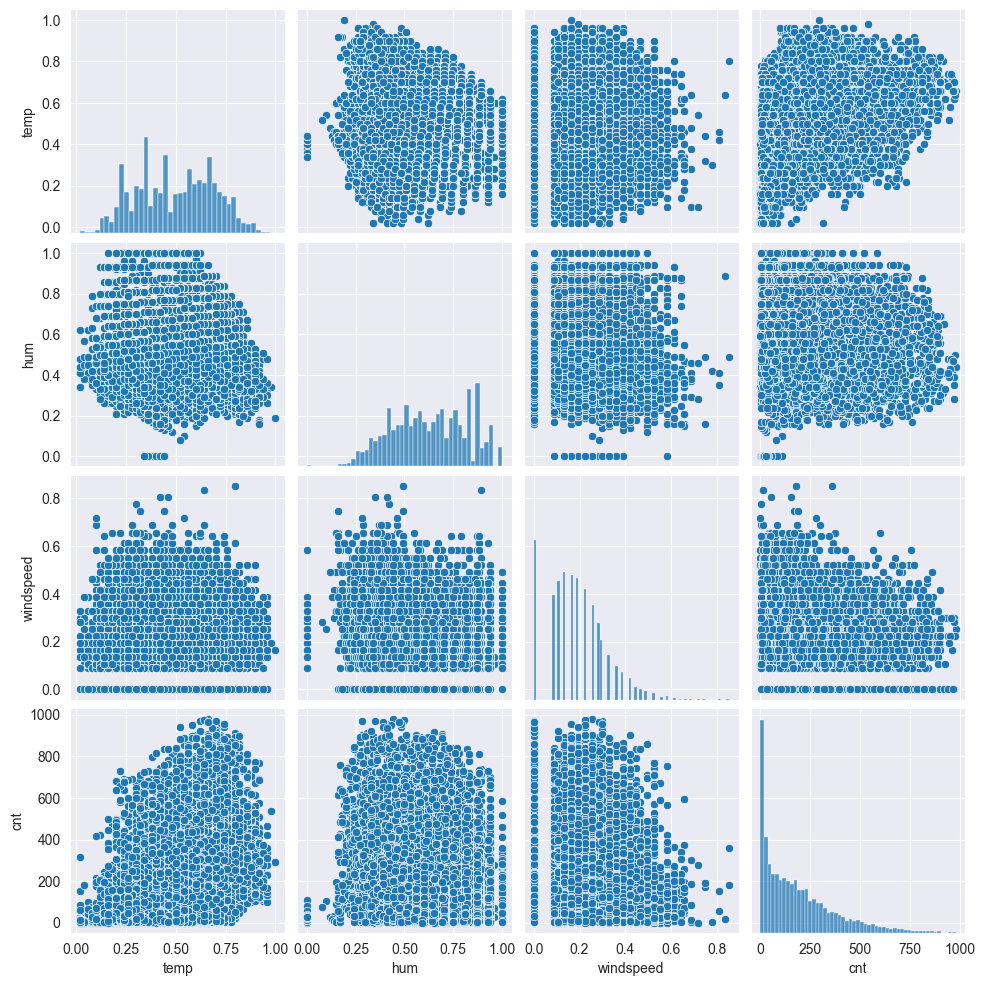

In [27]:
sns.pairplot(df[["temp","hum","windspeed","cnt"]])
plt.show()

In [28]:
df = df.drop("dteday", axis=1)

In [29]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

Regression model

In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

RandomForestRegressor()

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

GradientBoostingRegressor()

In [34]:
from sklearn.metrics import r2_score, mean_squared_error

In [35]:
def evaluate(model):

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    return r2, rmse

In [36]:
lr_r2, lr_rmse = evaluate(lr)
rf_r2, rf_rmse = evaluate(rf)
gb_r2, gb_rmse = evaluate(gb)

In [37]:
results = pd.DataFrame({
"Model":["Linear Regression","Random Forest","Gradient Boosting"],
"R2":[lr_r2, rf_r2, gb_r2],
"RMSE":[lr_rmse, rf_rmse, gb_rmse]
})

results

,Model,R2,RMSE
0,Linear Regression,0.387981,139.211452
1,Random Forest,0.944405,41.957601
2,Gradient Boosting,0.849399,69.056869


Random Forest was selected as the best model because it achieved the
highest R² score and the lowest RMSE value compared to the other
models. This indicates that it predicts bike rental demand more
accurately.


In [15]:
best_model = rf

best_model.fit(X_train, y_train)

NameError: name 'rf' is not defined

In [16]:
import joblib

joblib.dump(best_model,"model.joblib")

NameError: name 'best_model' is not defined